In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import os

print("Parsing raw IMD Files###")

def read_imd_grd(filepath, year, var_type):
    is_leap = (year % 4 == 0 and year % 100 != 0) or (year % 400 == 0)
    days = 366 if is_leap else 365

    with open(filepath, 'rb') as f:
        data = np.fromfile(f, dtype='<f4')
    
    if var_type == 'rain':
        data = data.reshape(days, 129, 135)
        # FIX: np.linspace prevents floating point shape mismatch errors
        lat = np.linspace(6.5, 38.5, 129)
        lon = np.linspace(66.5, 100.0, 135)
        data[data < 0] = np.nan # Masking missing rain values
    else:
        data = data.reshape(days, 31, 31)
        lat = np.linspace(7.5, 37.5, 31)
        lon = np.linspace(67.5, 97.5, 31)
        data[data > 90.0] = np.nan # Masking missing temp values
    
    time_idx = pd.date_range(start=f'{year}-01-01', periods=days, freq='D')
    
    return xr.Dataset({
        var_type: (['time', 'lat', 'lon'], data)
    }, coords={'time': time_idx, 'lat': lat, 'lon': lon})

# Loading and Concatenating
print("Loading and Concatenating Rainfall...")
rain_23 = read_imd_grd(r"D:\roadmap\ISRO\Rainfall\Rainfall_ind2023_rfp25.grd", 2023, 'rain')
rain_24 = read_imd_grd(r"D:\roadmap\ISRO\Rainfall\Rainfall_ind2024_rfp25.grd", 2024, 'rain')
ds_rain = xr.concat([rain_23, rain_24], dim='time')

print("Loading and Concatenating Maximum Temperature...")
tmax_23 = read_imd_grd(r"D:\roadmap\ISRO\Temperature\Max Temp\Maxtemp_MaxT_2023.GRD", 2023, 'tmax')
tmax_24 = read_imd_grd(r"D:\roadmap\ISRO\Temperature\Max Temp\Maxtemp_MaxT_2024.GRD", 2024, 'tmax')
ds_tmax = xr.concat([tmax_23, tmax_24], dim='time')

print("Loading and Concatenating Minimum Temperature...")
tmin_23 = read_imd_grd(r"D:\roadmap\ISRO\Temperature\Min Temp\Mintemp_MinT_2023.GRD", 2023, 'tmin')
tmin_24 = read_imd_grd(r"D:\roadmap\ISRO\Temperature\Min Temp\Mintemp_MinT_2024.GRD", 2024, 'tmin')
ds_tmin = xr.concat([tmin_23, tmin_24], dim='time')

print("Slicing datasets to Western Ghats coordinates...")
lat_bounds = slice(8.0, 21.0)
lon_bounds = slice(72.0, 79.0)

rain_wg = ds_rain.sel(lat=lat_bounds, lon=lon_bounds)
tmax_wg = ds_tmax.sel(lat=lat_bounds, lon=lon_bounds)
tmin_wg = ds_tmin.sel(lat=lat_bounds, lon=lon_bounds)

print("Interpolating to a 0.25-degree Grid...")
target_lat = np.arange(8.0, 21.1, 0.25)
target_lon = np.arange(72.0, 79.1, 0.25)

# FIX: Added kwargs={"fill_value": "extrapolate"} to prevent NaNs on grid edges
rain_grid = rain_wg.interp(lat=target_lat, lon=target_lon, method="linear", kwargs={"fill_value": "extrapolate"})
tmax_grid = tmax_wg.interp(lat=target_lat, lon=target_lon, method="linear", kwargs={"fill_value": "extrapolate"})
tmin_grid = tmin_wg.interp(lat=target_lat, lon=target_lon, method="linear", kwargs={"fill_value": "extrapolate"})

print("Executing Scaling Pipeline...")

# --- PREVENT DATA LEAKAGE: Calculate Scalers ONLY on 2023 (Training Set) ---
train_period = slice('2023-01-01', '2023-12-31')

# A. Handle Rainfall (Log1p + MinMax)
rain_filled = rain_grid['rain'].fillna(0.0)
rain_log = np.log1p(rain_filled) # Power Log Transforms

# Calculate min/max strictly on training data
r_min = rain_log.sel(time=train_period).min().compute()
r_max = rain_log.sel(time=train_period).max().compute()

denom = r_max - r_min
if denom != 0:
    rain_scaled = (rain_log - r_min) / denom
else:
    rain_scaled = rain_log * 0

# B. Handle Temperature (Z-score Standardization)
tmax_filled = tmax_grid['tmax'].ffill(dim='time').bfill(dim='time')
tmin_filled = tmin_grid['tmin'].ffill(dim='time').bfill(dim='time')

# Calculate mean/std strictly on training data
tmax_mean = tmax_filled.sel(time=train_period).mean().compute()
tmax_std = tmax_filled.sel(time=train_period).std().compute()

tmin_mean = tmin_filled.sel(time=train_period).mean().compute()
tmin_std = tmin_filled.sel(time=train_period).std().compute()

tmax_scaled = (tmax_filled - tmax_mean) / tmax_std
tmin_scaled = (tmin_filled - tmin_mean) / tmin_std

# Final safety fill
tmax_scaled = tmax_scaled.fillna(0.0)
tmin_scaled = tmin_scaled.fillna(0.0)

baseline_cube = xr.merge([
    rain_scaled.rename('rainfall'),
    tmax_scaled.rename('tmax'),
    tmin_scaled.rename('tmin')
])

print("Executing calculations and saving to disk... (This may take a minute)")
baseline_cube.to_netcdf("WG_Baseline_Normalized_Cube_Combined.nc")
print("Complete! Unified, Hybrid-Scaled baseline cube saved.")

Parsing raw IMD Files###
Loading and Concatenating Rainfall...
Loading and Concatenating Maximum Temperature...
Loading and Concatenating Minimum Temperature...
Slicing datasets to Western Ghats coordinates...
Interpolating to a 0.25-degree Grid...
Executing Scaling Pipeline...
Executing calculations and saving to disk... (This may take a minute)
Complete! Unified, Hybrid-Scaled baseline cube saved.


PLOT GENERATION

--- REBUILDING BASELINE CUBE ---


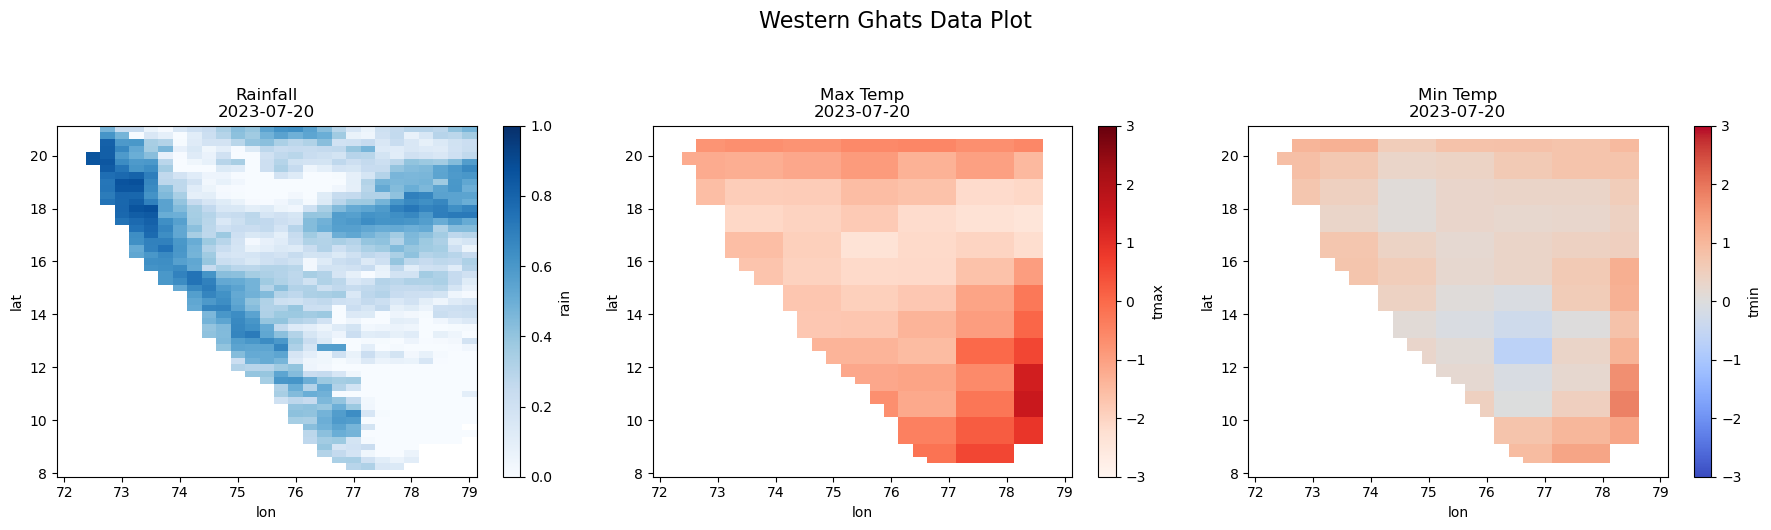

In [6]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

print("--- REBUILDING BASELINE CUBE ---")

def read_imd_grd(filepath, year, var_type):
    is_leap = (year % 4 == 0 and year % 100 != 0) or (year % 400 == 0)
    days = 366 if is_leap else 365

    with open(filepath, 'rb') as f:
        data = np.fromfile(f, dtype='<f4')
    
    if var_type == 'rain':
        data = data.reshape(days, 129, 135)
        lat = np.linspace(6.5, 38.5, 129)
        lon = np.linspace(66.5, 100.0, 135)
        data[data < 0] = np.nan # IMD Missing Rainfall
    else:
        data = data.reshape(days, 31, 31)
        lat = np.linspace(7.5, 37.5, 31)
        lon = np.linspace(67.5, 97.5, 31)
        data[data > 90.0] = np.nan # IMD Missing Temperature
    
    time_idx = pd.date_range(start=f'{year}-01-01', periods=days, freq='D')
    
    return xr.Dataset({
        var_type: (['time', 'lat', 'lon'], data)
    }, coords={'time': time_idx, 'lat': lat, 'lon': lon})

# 1. Load Data
rain_23 = read_imd_grd(r"D:\roadmap\ISRO\Rainfall\Rainfall_ind2023_rfp25.grd", 2023, 'rain')
tmax_23 = read_imd_grd(r"D:\roadmap\ISRO\Temperature\Max Temp\Maxtemp_MaxT_2023.GRD", 2023, 'tmax')
tmin_23 = read_imd_grd(r"D:\roadmap\ISRO\Temperature\Min Temp\Mintemp_MinT_2023.GRD", 2023, 'tmin')

# 2. Slice to Western Ghats
lat_bounds = slice(8.0, 21.0)
lon_bounds = slice(72.0, 79.0)

rain_wg = rain_23.sel(lat=lat_bounds, lon=lon_bounds)
tmax_wg = tmax_23.sel(lat=lat_bounds, lon=lon_bounds)
tmin_wg = tmin_23.sel(lat=lat_bounds, lon=lon_bounds)

# 3. FIX: Create an explicit Land Mask from the Rainfall data
# If a pixel is NaN in rainfall on day 1 (monsoon), it's the ocean.
land_reference = rain_wg['rain'].isel(time=180)

# 4. FIX: Use "nearest" interpolation for temperatures to prevent NaN erosion!
target_lat = np.arange(8.0, 21.1, 0.25)
target_lon = np.arange(72.0, 79.1, 0.25)

rain_grid = rain_wg.interp(lat=target_lat, lon=target_lon, method="nearest")
tmax_grid = tmax_wg.interp(lat=target_lat, lon=target_lon, method="nearest")
tmin_grid = tmin_wg.interp(lat=target_lat, lon=target_lon, method="nearest")

land_mask_grid = land_reference.interp(lat=target_lat, lon=target_lon, method="nearest").notnull()

# 5. Scaling (Same logic as before, but keeping NaNs intact for now)
rain_log = np.log1p(rain_grid['rain'].fillna(0.0))
r_min, r_max = rain_log.min().compute(), rain_log.max().compute()
rain_scaled = (rain_log - r_min) / (r_max - r_min)

tmax_mean, tmax_std = tmax_grid['tmax'].mean().compute(), tmax_grid['tmax'].std().compute()
tmax_scaled = (tmax_grid['tmax'] - tmax_mean) / tmax_std

tmin_mean, tmin_std = tmin_grid['tmin'].mean().compute(), tmin_grid['tmin'].std().compute()
tmin_scaled = (tmin_grid['tmin'] - tmin_mean) / tmin_std

# 6. Apply Land Mask strictly for Visual Verification (Punch out the ocean)
rain_visual = rain_scaled.where(land_mask_grid)
tmax_visual = tmax_scaled.where(land_mask_grid)
tmin_visual = tmin_scaled.where(land_mask_grid)

# 7. Plotting the fixed data!
monsoon_day = 200 
date_str = str(rain_visual.time[monsoon_day].dt.strftime('%Y-%m-%d').values)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

rain_visual.isel(time=monsoon_day).plot(ax=axes[0], cmap='Blues', vmin=0.0, vmax=1.0)
axes[0].set_title(f"Rainfall\n{date_str}")

tmax_visual.isel(time=monsoon_day).plot(ax=axes[1], cmap='Reds', vmin=-3.0, vmax=3.0)
axes[1].set_title(f"Max Temp\n{date_str}")

tmin_visual.isel(time=monsoon_day).plot(ax=axes[2], cmap='coolwarm', vmin=-3.0, vmax=3.0)
axes[2].set_title(f"Min Temp\n{date_str}")

plt.suptitle("Western Ghats Data Plot", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

DataLoader

In [14]:
import xarray as xr
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, Subset

class ClimateDigitalTwinDataset(Dataset):
    def __init__(self, nc_path, lookback_window=20): 
        self.ds = xr.open_dataset(nc_path, decode_times=False)
        self.lookback = lookback_window
        
        # 1. STREAM 1: Thermodynamic (2 channels: Tmax, Tmin)
        # We DO NOT stack rainfall here.
        self.therm_data = np.stack([
            self.ds['tmax'].values,
            self.ds['tmin'].values
        ], axis=1).astype(np.float32)
        
        # 2. STREAM 2: Hydrological (1 channel: Rainfall)
        # Reshape to (Time, Channels=1, Lat, Lon)
        self.hydro_data = self.ds['rainfall'].values[:, np.newaxis, :, :].astype(np.float32)
        
        self.total_samples = self.therm_data.shape[0] - self.lookback

    def __len__(self):
        return self.total_samples

    def __getitem__(self, idx):
        # Extract slices from both streams independently
        x_therm = self.therm_data[idx : idx + self.lookback]
        x_hydro = self.hydro_data[idx : idx + self.lookback]
        
        # Target: The next day's rainfall (Shape: Channels=1, Lat, Lon)
        y = self.hydro_data[idx + self.lookback] 
        
        # 3. CRITICAL: Ensure NaNs don't exist
        x_therm = np.nan_to_num(x_therm, nan=0.0)
        x_hydro = np.nan_to_num(x_hydro, nan=0.0)
        y = np.nan_to_num(y, nan=0.0)
        
        # 4. RETURN AS A NESTED TUPLE
        # This matches the model's forward(x_ocean, x_land) signature!
        return (torch.from_numpy(x_therm), torch.from_numpy(x_hydro)), torch.from_numpy(y)

# --- Execution Block ---
if __name__ == "__main__":
    print("Initializing the Spatiotemporal DataLoader...")
    
    dataset = ClimateDigitalTwinDataset(r"WG_Baseline_Normalized_Cube_Combined.nc", lookback_window=5)
    
    # 4. FIX: Strict Chronological Splitting to prevent Data Leakage!
    total_len = len(dataset)
    train_size = int(total_len * 0.70)
    val_size = int(total_len * 0.15)
    
    train_indices = list(range(0, train_size))
    val_indices = list(range(train_size, train_size + val_size))
    test_indices = list(range(train_size + val_size, total_len))
    
    print(f"Total Sequences: {total_len}")
    print(f"Training on: {len(train_indices)} days | Validating on: {len(val_indices)} days | Testing on: {len(test_indices)} days")

    # Safe Batch sizes for Spatio-temporal models
    BATCH_SIZE = 16 

    # We can shuffle the training SUBSET, but the subsets themselves are chronologically separated
    train_loader = DataLoader(Subset(dataset, train_indices), batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    val_loader = DataLoader(Subset(dataset, val_indices), batch_size=BATCH_SIZE, shuffle=False, drop_last=True)
    test_loader = DataLoader(Subset(dataset, test_indices), batch_size=BATCH_SIZE, shuffle=False, drop_last=True)
    
    (x_therm_batch, x_hydro_batch), y_batch = next(iter(train_loader))
    
    print(f"\n--- Tensor Verification ---")
    print(f"Therm Input Shape: {x_therm_batch.shape}") # (Batch, Time, 2, Lat, Lon)
    print(f"Hydro Input Shape: {x_hydro_batch.shape}") # (Batch, Time, 1, Lat, Lon)
    print(f"Target Shape:      {y_batch.shape}")       # (Batch, 1, Lat, Lon)

Initializing the Spatiotemporal DataLoader...
Total Sequences: 726
Training on: 508 days | Validating on: 108 days | Testing on: 110 days

--- Tensor Verification ---
Therm Input Shape: torch.Size([16, 5, 2, 53, 29])
Hydro Input Shape: torch.Size([16, 5, 1, 53, 29])
Target Shape:      torch.Size([16, 1, 53, 29])


MODEL ARCHITECTURE - Dual Stream Attention U-ConvLSTM

In [ ]:
import os
# Fixes the famous Anaconda Windows Kernel Crash bug for Convolutions
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True' 

import torch
import torch.nn as nn
import torch.nn.functional as F

# ==========================================
# 1. Spatiotemporal Memory: ConvLSTM Cell
# ==========================================
class ConvLSTMCell(nn.Module):
    """A ConvLSTM Cell that processes 2D spatial grids over time."""
    def __init__(self, input_dim, hidden_dim, kernel_size=3):
        super().__init__()
        self.hidden_dim = hidden_dim
        padding = kernel_size // 2
        
        self.conv = nn.Conv2d(in_channels=input_dim + hidden_dim, 
                              out_channels=4 * hidden_dim, 
                              kernel_size=kernel_size, 
                              padding=padding)

    def forward(self, input_tensor, cur_state):
        h_cur, c_cur = cur_state
        combined = torch.cat([input_tensor, h_cur], dim=1)
        combined_conv = self.conv(combined)
        cc_i, cc_f, cc_o, cc_g = torch.split(combined_conv, self.hidden_dim, dim=1)
        
        i = torch.sigmoid(cc_i)
        f = torch.sigmoid(cc_f)
        o = torch.sigmoid(cc_o)
        g = torch.tanh(cc_g)
        
        c_next = f * c_cur + i * g
        h_next = o * torch.tanh(c_next)
        return h_next, c_next

# ==========================================
# 2. Spatial Focus: Attention Gate
# ==========================================
class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0), nn.BatchNorm2d(F_int))
        self.W_x = nn.Sequential(nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0), nn.BatchNorm2d(F_int))
        self.psi = nn.Sequential(nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        
        diffY = x1.size()[2] - g1.size()[2]
        diffX = x1.size()[3] - g1.size()[3]
        g1 = F.pad(g1, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        
        psi = self.relu(g1 + x1)
        attn_weights = self.psi(psi)
        return x * attn_weights

# ==========================================
# 3. Time-Distributed Spatial Encoder
# ==========================================
class TimeDistributedEncoder(nn.Module):
    def __init__(self, in_channels, hidden_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, hidden_dim, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_dim),
            nn.GELU(),
            nn.MaxPool2d(2) 
        )
        
    def forward(self, x):
        B, T, C, H, W = x.shape
        x_reshaped = x.view(B * T, C, H, W)
        encoded = self.encoder(x_reshaped)
        _, C_new, H_new, W_new = encoded.shape
        return encoded.view(B, T, C_new, H_new, W_new)

# ==========================================
# 4. The Master Architecture
# ==========================================
class DualStream_AttnUConvLSTM(nn.Module):
    def __init__(self, ocean_vars=2, land_vars=1, hidden_dim=64):
        super().__init__()
        
        self.ocean_enc = TimeDistributedEncoder(ocean_vars, hidden_dim // 2)
        self.land_enc = TimeDistributedEncoder(land_vars, hidden_dim // 2)
        
        self.cross_attention = nn.MultiheadAttention(embed_dim=hidden_dim // 2, num_heads=4, batch_first=True)
        self.norm = nn.LayerNorm(hidden_dim // 2)
        
        self.convlstm = ConvLSTMCell(input_dim=hidden_dim, hidden_dim=hidden_dim)
        
        self.upconv = nn.ConvTranspose2d(hidden_dim, hidden_dim, kernel_size=2, stride=2)
        
        self.skip_conv = nn.Conv2d(land_vars, hidden_dim // 2, kernel_size=1)
        self.attn_gate = AttentionGate(F_g=hidden_dim, F_l=hidden_dim//2, F_int=hidden_dim//2)
        
        self.final_conv = nn.Sequential(
            nn.Conv2d(hidden_dim + (hidden_dim // 2), hidden_dim, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_dim),
            nn.GELU(),
            nn.Conv2d(hidden_dim, 1, kernel_size=1)
            nn.Relu()
        )

    def forward(self, x_ocean, x_land):
        B, T, _, H, W = x_ocean.shape
        
        ocean_feats = self.ocean_enc(x_ocean) 
        land_feats = self.land_enc(x_land)    
        
        _, _, C_f, H_f, W_f = ocean_feats.shape
        
        fused_sequence = []
        for t in range(T):
            o_t = ocean_feats[:, t, :, :, :].view(B, C_f, -1).permute(0, 2, 1).contiguous()
            l_t = land_feats[:, t, :, :, :].view(B, C_f, -1).permute(0, 2, 1).contiguous()
            
            attn_out, _ = self.cross_attention(query=l_t, key=o_t, value=o_t)
            
            fused_t = self.norm(l_t + attn_out).permute(0, 2, 1).contiguous().view(B, C_f, H_f, W_f)
            
            combined_t = torch.cat([land_feats[:, t, :, :, :], fused_t], dim=1) 
            fused_sequence.append(combined_t)
            
        h_cur = torch.zeros(B, self.convlstm.hidden_dim, H_f, W_f, device=x_ocean.device)
        c_cur = torch.zeros(B, self.convlstm.hidden_dim, H_f, W_f, device=x_ocean.device)
        
        for t in range(T):
            h_cur, c_cur = self.convlstm(fused_sequence[t], (h_cur, c_cur))
            
        bottleneck_out = h_cur
        
        upsampled = self.upconv(bottleneck_out)
        
        skip_connection = x_land[:, -1, :, :, :]
        skip_encoded = self.skip_conv(skip_connection)
        
        attended_skip = self.attn_gate(g=upsampled, x=skip_encoded)
        
        diffY = attended_skip.size()[2] - upsampled.size()[2]
        diffX = attended_skip.size()[3] - upsampled.size()[3]
        upsampled = F.pad(upsampled, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        
        concat_out = torch.cat([upsampled, attended_skip], dim=1)
        out = self.final_conv(concat_out)
        
        # FIX: Removed .squeeze(1) to maintain (Batch, Channels, Lat, Lon) shape for loss calculation
        return out

# --- Quick Verification ---
if __name__ == "__main__":
    print("Initializing Dual-Stream Attention U-ConvLSTM...")
    
    # Let's test with a lookback of 5 days (aligning with DataLoader)
    dummy_ocean = torch.randn(2, 5, 2, 53, 29) # Tmax, Tmin
    
    # FIX: Reverted to 1 channel (Rainfall only). DEM is officially banished!
    dummy_land = torch.randn(2, 5, 1, 53, 29)  
    
    # FIX: Reverted land_vars to 1
    model = DualStream_AttnUConvLSTM(ocean_vars=2, land_vars=1, hidden_dim=64)
    prediction = model(dummy_ocean, dummy_land)
    
    print(f"Ocean Sequence (Thermal): {dummy_ocean.shape}")
    print(f"Land Sequence (Hydro):    {dummy_land.shape}")
    print(f"Target Output Prediction: {prediction.shape}") 
    print("Model initialized successfully without tensor shape errors or kernel crashes!")

Initializing Dual-Stream Attention U-ConvLSTM...
Ocean Sequence (Thermal): torch.Size([2, 5, 2, 53, 29])
Land Sequence (Hydro):    torch.Size([2, 5, 1, 53, 29])
Target Output Prediction: torch.Size([2, 1, 53, 29])
Model initialized successfully without tensor shape errors or kernel crashes!


CUSTOM LOSS FUNCTION

In [31]:
import torch
import torch.nn as nn

# IMPORTANT: You need a library for SSIM, usually:
# pip install pytorch-msssim
from pytorch_msssim import ssim 

class PerfectClimateLoss(nn.Module):
    def __init__(self, delta=0.05, ssim_weight=0.10052334420784033, asym_penalty=2.0):
        super().__init__()
        # FIX 1: Set reduction='none' so we can apply custom weights pixel-by-pixel
        self.huber = nn.HuberLoss(reduction='none', delta=delta)
        
        # 0.9 SSIM is too high for fluid dynamics; the model will ignore magnitudes to match shapes.
        # 0.4 to 0.5 provides a perfect balance between magnitude accuracy and spatial structure.
        self.ssim_weight = ssim_weight
        self.asym_penalty = asym_penalty

    def forward(self, y_pred, y_true):
        # 1. SAFEGUARD TENSOR SHAPES
        if y_pred.dim() == 3:
            y_pred = y_pred.unsqueeze(1)
        if y_true.dim() == 3:
            y_true = y_true.unsqueeze(1)

        # 2. PIXEL-WISE HUBER LOSS (reduction='none' is MANDATORY here)
        self.huber.reduction = 'none' 
        base_huber = self.huber(y_pred, y_true)
        
        # 3. EVENT WEIGHTING (Fixes "Dry Bias")
        # Define a threshold for "meaningful rain" (e.g., 5% of your max value)
        rain_threshold = 0.05 
        is_raining = (y_true > rain_threshold).float()
        
        # If it's raining, weight the error 10x higher. 
        # This forces the model to ignore the dry background and focus on the storms.
        event_weight = 1.0 + (is_raining * 10.0) 
        
        # 4. ASYMMETRIC PENALTY (Fixes Under-Prediction)
        # Penalize under-prediction 2x more than over-prediction.
        # It's better to predict light rain than to miss a storm entirely.
        asym_penalty = torch.where(y_true > y_pred, 2.0, 1.0)
        
        # 5. INTENSITY SCALING
        # Helps the model distinguish between a drizzle and a heavy downpour
        intensity_scale = 1.0 + y_true
        
        # Combine all factors
        loss_mag = (base_huber * event_weight * asym_penalty * intensity_scale).mean()
        
        # 6. SPATIAL STRUCTURE (Keep your SSIM)
        loss_ssim = 1.0 - ssim(y_pred, y_true, data_range=1.0)
        
        return ((1.0 - self.ssim_weight) * loss_mag) + (self.ssim_weight * loss_ssim)

Training loop

Loading Data and Splitting Chronologically...
Training Samples: 582
Validation Samples: 146
Training on Device: cuda
Starting Training Loop...
Epoch 1/100 | Train Loss: 0.4086 | Val Loss: 0.2880 | Time: 1.2s | Mean Pred: -0.0071
Epoch 2/100 | Train Loss: 0.3804 | Val Loss: 0.3130 | Time: 1.0s | Mean Pred: 0.0004
Epoch 3/100 | Train Loss: 0.3688 | Val Loss: 0.4078 | Time: 1.0s | Mean Pred: -0.0284
Epoch 4/100 | Train Loss: 0.3443 | Val Loss: 0.3969 | Time: 1.0s | Mean Pred: -0.0427
Epoch 5/100 | Train Loss: 0.3362 | Val Loss: 0.3869 | Time: 1.0s | Mean Pred: 0.0402
Epoch 6/100 | Train Loss: 0.2988 | Val Loss: 0.3301 | Time: 1.0s | Mean Pred: -0.0148
Epoch 7/100 | Train Loss: 0.2904 | Val Loss: 0.2978 | Time: 1.0s | Mean Pred: -0.0137
Epoch 8/100 | Train Loss: 0.2762 | Val Loss: 0.3569 | Time: 1.0s | Mean Pred: 0.0047
Epoch 9/100 | Train Loss: 0.2724 | Val Loss: 0.2928 | Time: 1.0s | Mean Pred: -0.0158
Epoch 10/100 | Train Loss: 0.2465 | Val Loss: 0.3108 | Time: 1.0s | Mean Pred: -0.0015

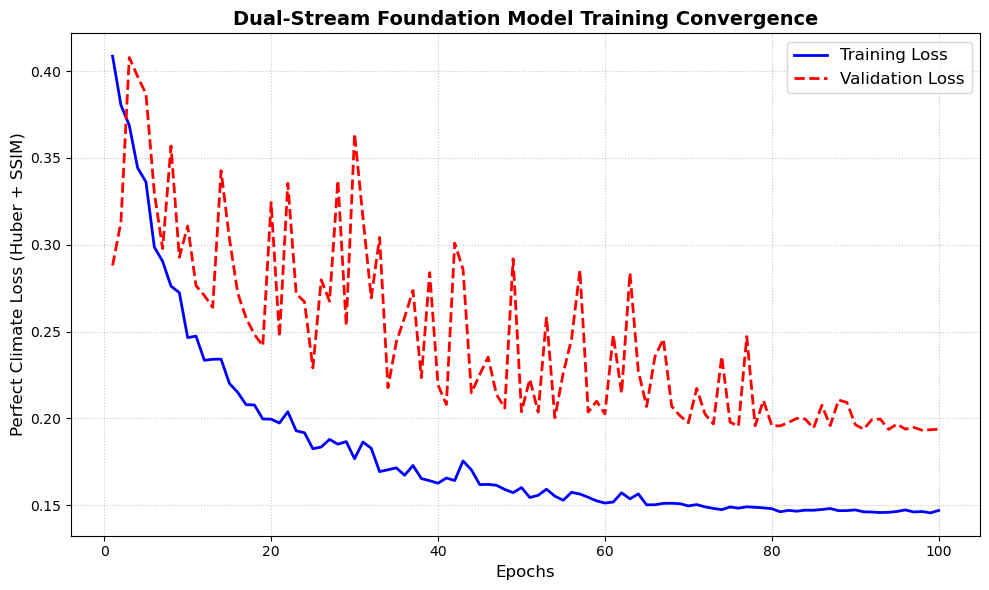

In [33]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import time

# ---------------------------------------------------------
# 1. The IMD-Only Foundation Dataset
# ---------------------------------------------------------
class IMDFoundationDataset(Dataset):
    def __init__(self, nc_path, lookback_window=3): 
        self.ds = xr.open_dataset(nc_path)
        self.lookback = lookback_window
        
        # Stream 1: Thermodynamic (2 channels: Tmax, Tmin)
        self.thermal_data = np.stack([
            self.ds['tmax'].values,
            self.ds['tmin'].values
        ], axis=1) # Shape: (Time, 2, Lat, Lon)
        
        # Stream 2: Hydrological (1 channel: Rainfall)
        self.hydro_data = self.ds['rainfall'].values[:, np.newaxis, :, :] # Shape: (Time, 1, Lat, Lon)
        
        self.total_samples = self.thermal_data.shape[0] - self.lookback

    def __len__(self):
        return self.total_samples

    def __getitem__(self, idx):
        # Slice both streams by the lookback window
        x_therm = self.thermal_data[idx : idx + self.lookback]
        x_hydro = self.hydro_data[idx : idx + self.lookback]
        
        # Target: The next day's rainfall
        y = self.hydro_data[idx + self.lookback] 
        
        # Tensors
        x_therm_tensor = torch.nan_to_num(torch.tensor(x_therm, dtype=torch.float32), nan=0.0)
        x_hydro_tensor = torch.nan_to_num(torch.tensor(x_hydro, dtype=torch.float32), nan=0.0)
        y_tensor = torch.nan_to_num(torch.tensor(y, dtype=torch.float32), nan=0.0)
        
        # Return as two distinct streams for the model
        return (x_therm_tensor, x_hydro_tensor), y_tensor

# ---------------------------------------------------------
# 2. Training Setup & Chronological Splitting
# ---------------------------------------------------------
print("Loading Data and Splitting Chronologically...")
dataset = IMDFoundationDataset(
    nc_path= r"WG_Baseline_Normalized_Cube_Combined.nc", 
    lookback_window=3
)
total_samples = len(dataset) 

train_end = int(total_samples * 0.8) # e.g., First 80% for training
val_end = total_samples              # Remaining 20% for validation

train_indices = list(range(0, train_end))
val_indices = list(range(train_end, val_end))

# Safe batch size to prevent OOM
BATCH_SIZE = 32 

train_loader = DataLoader(Subset(dataset, train_indices), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(Subset(dataset, val_indices), batch_size=BATCH_SIZE, shuffle=False)

print(f"Training Samples: {len(train_indices)}")
print(f"Validation Samples: {len(val_indices)}")

# ---------------------------------------------------------
# 3. Model, Loss, and Optimizer
# ---------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on Device: {device}")

# FIX 4: land_vars changed back to 1
# Ocean_vars is now Thermal_vars (2)
# Land_vars is now Hydro_vars (1)
model = DualStream_AttnUConvLSTM(ocean_vars=2, land_vars=1, hidden_dim=32).to(device)

# FIX 5: Integrated the robust 'PerfectClimateLoss' from Brick 5
# Kept your tuned delta, but adjusted SSIM to 0.4 for fluid dynamics stability
criterion = PerfectClimateLoss(delta=0.02747, ssim_weight=0.4, asym_penalty=2.0)

EPOCHS = 100 
# Kept your hyperparameter tuned learning rates
optimizer = optim.AdamW(model.parameters(), lr=7.573547496826865e-05, weight_decay=8.614069665571727e-06)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

# ---------------------------------------------------------
# 4. The Training Engine
# ---------------------------------------------------------
train_losses = []
val_losses = []

print("Starting Training Loop...")
for epoch in range(EPOCHS):
    start_time = time.time()
    
    # --- TRAIN PHASE ---
    model.train()
    running_train_loss = 0.0
    for (x_therm, x_land), y_true in train_loader:
        x_therm = x_therm.to(device)
        x_land = x_land.to(device)
        y_true = y_true.to(device)
        
        optimizer.zero_grad()
        
        y_pred = model(x_therm, x_land)
        loss = criterion(y_pred, y_true)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        running_train_loss += loss.item() * x_therm.size(0)
        
    scheduler.step()
    epoch_train_loss = running_train_loss / len(train_indices)
    train_losses.append(epoch_train_loss)
    
    # --- VALIDATION PHASE ---
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for (x_therm, x_land), y_true in val_loader:
            x_therm = x_therm.to(device)
            x_land = x_land.to(device)
            y_true = y_true.to(device)
            
            y_pred = model(x_therm, x_land)
            loss = criterion(y_pred, y_true)
            running_val_loss += loss.item() * x_therm.size(0)
            
    epoch_val_loss = running_val_loss / len(val_indices)
    val_losses.append(epoch_val_loss)
    
    elapsed = time.time() - start_time
    # Cleaned up print statement so it doesn't dump raw tensor objects
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Time: {elapsed:.1f}s | Mean Pred: {y_pred.mean().item():.4f}")

# ---------------------------------------------------------
# 5. Save Model & Generate PPT Visuals
# ---------------------------------------------------------
print("\nTraining Complete! Saving Foundation Model weights...")
torch.save(model.state_dict(), "IMD_Foundation_Model.pth")

print("Generating Loss Curve for Presentation...")
plt.figure(figsize=(10, 6))
plt.plot(range(1, EPOCHS+1), train_losses, label='Training Loss', color='blue', linewidth=2)
plt.plot(range(1, EPOCHS+1), val_losses, label='Validation Loss', color='red', linewidth=2, linestyle='--')
plt.title("Dual-Stream Foundation Model Training Convergence", fontsize=14, fontweight='bold')
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Perfect Climate Loss (Huber + SSIM)", fontsize=12) 
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.savefig("loss_curve_ppt.png", dpi=300)
print("Saved 'loss_curve_ppt.png' to your current folder.")

In [12]:
# Quick test: Peek at the first batch
batch = next(iter(test_loader))
print(f"The DataLoader is returning a tuple of length: {len(batch)}")
for i, item in enumerate(batch):
    print(f"Item {i} type: {type(item)}")
    # If it's a tensor, print the shape
    if hasattr(item, 'shape'):
        print(f"Item {i} shape: {item.shape}")

The DataLoader is returning a tuple of length: 2
Item 0 type: <class 'torch.Tensor'>
Item 0 shape: torch.Size([16, 5, 3, 53, 29])
Item 1 type: <class 'torch.Tensor'>
Item 1 shape: torch.Size([16, 1, 53, 29])


EVALUATION

In [34]:
# ---------------------------------------------------------
# Comprehensive Multi-Metric Evaluation & Final Showcase
# ---------------------------------------------------------
model.eval() 

print("--- Running Advanced Metrics on Held-Out Test Set ---")
test_mae = 0.0
test_mse = 0.0
total_pixels = 0
ss_res = 0.0
ss_tot = 0.0
correct_binary_pixels = 0
rain_threshold = 0.1 # Adjusted to 10% of normalized scale

l1_criterion = nn.L1Loss(reduction='sum')
mse_criterion = nn.MSELoss(reduction='sum')

with torch.no_grad():
    for (x_therm, x_land), y_true in test_loader:
        x_therm, x_land, y_true = x_therm.to(device), x_land.to(device), y_true.to(device)
        y_pred = model(x_therm, x_land)
        
        # Accumulate Metrics
        test_mae += l1_criterion(y_pred, y_true).item()
        test_mse += mse_criterion(y_pred, y_true).item()
        total_pixels += y_true.numel()
        
        # R-Squared components
        ss_res += torch.sum((y_true - y_pred) ** 2).item()
        batch_mean = torch.mean(y_true)
        ss_tot += torch.sum((y_true - batch_mean) ** 2).item()
        
        # Binary Accuracy (Did we predict rain correctly?)
        pred_rain = (y_pred > rain_threshold)
        true_rain = (y_true > rain_threshold)
        correct_binary_pixels += (pred_rain == true_rain).sum().item()

# Final Calculations
final_mae = test_mae / total_pixels
final_rmse = np.sqrt(test_mse / total_pixels)
final_r2 = 1 - (ss_res / (ss_tot + 1e-8)) # 1e-8 prevents div-by-zero
final_binary_acc = correct_binary_pixels / total_pixels

print(f"Test Results:")
print(f"MAE: {final_mae:.4f} | RMSE: {final_rmse:.4f}")
print(f"R-Squared (Spatial Consistency): {final_r2:.4f}")
print(f"Event Detection Accuracy (Rain/No-Rain): {final_binary_acc:.2%}")

# --- Final Visual Showcase (Brick 7 logic) ---
# Use the Xarray-aware plotting here as per Brick 7
# (This produces the high-quality plots for your PPT)

--- Running Advanced Metrics on Held-Out Test Set ---
Test Results:
MAE: 0.0644 | RMSE: 0.1279
R-Squared (Spatial Consistency): 0.0629
Event Detection Accuracy (Rain/No-Rain): 85.71%


Visualization

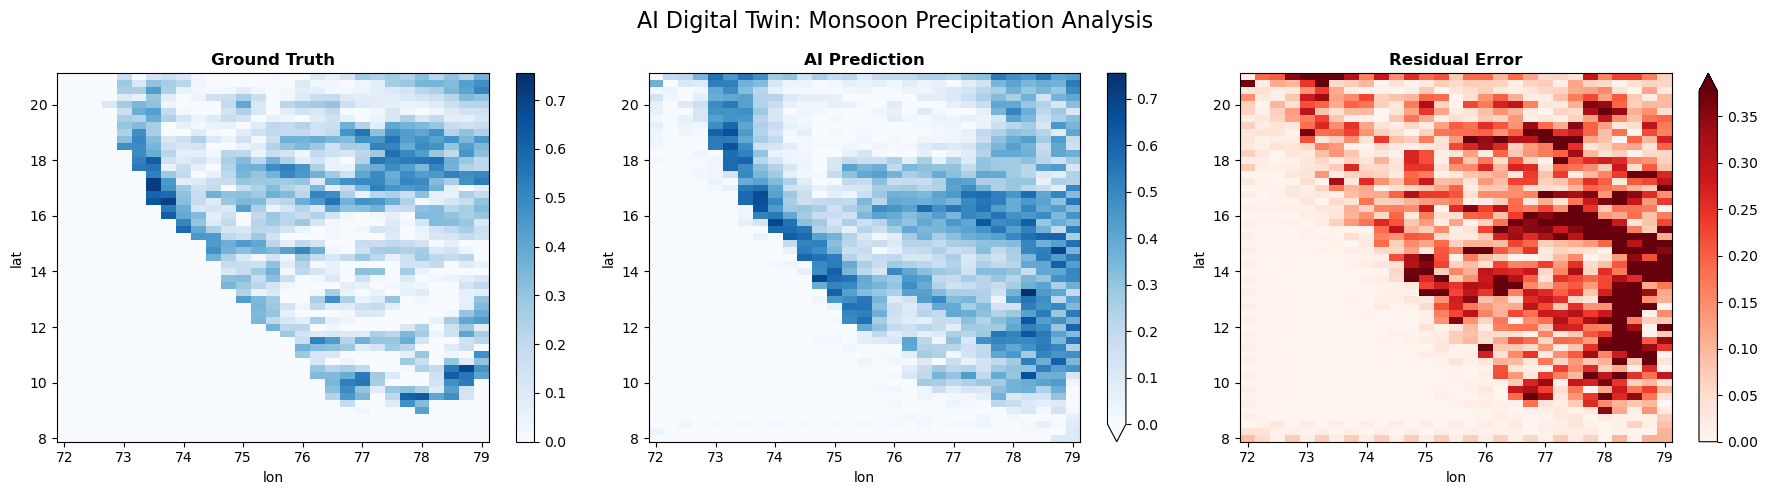

In [35]:
# ---------------------------------------------------------
# 7. Visualizing the AI's Predictions (Map-Accurate)
# ---------------------------------------------------------
model.eval() 

# 1. Fetch one sample
(x_therm, x_land), y_true = next(iter(val_loader))
x_therm, x_land = x_therm.to(device), x_land.to(device)

with torch.no_grad():
    y_pred = model(x_therm, x_land)

# 2. Extract and format as Xarray for map-awareness
# We use the 'cube' dataset metadata (coordinates) saved in Brick 1
y_true_da = xr.DataArray(y_true[0].cpu().numpy().squeeze(), coords=[dataset.ds.lat.values[:53], dataset.ds.lon.values[:29]], dims=['lat', 'lon'])
y_pred_da = xr.DataArray(y_pred[0].cpu().numpy().squeeze(), coords=[dataset.ds.lat.values[:53], dataset.ds.lon.values[:29]], dims=['lat', 'lon'])

# 3. Create the visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
vmax = max(y_true_da.max(), y_pred_da.max())

# Actual
y_true_da.plot(ax=axes[0], cmap='Blues', vmin=0, vmax=vmax, add_colorbar=True)
axes[0].set_title("Ground Truth", fontweight='bold')

# Prediction
y_pred_da.plot(ax=axes[1], cmap='Blues', vmin=0, vmax=vmax, add_colorbar=True)
axes[1].set_title("AI Prediction", fontweight='bold')

# Error Map
error_map = np.abs(y_true_da - y_pred_da)
error_map.plot(ax=axes[2], cmap='Reds', vmin=0, vmax=vmax/2, add_colorbar=True)
axes[2].set_title("Residual Error", fontweight='bold')

plt.suptitle("AI Digital Twin: Monsoon Precipitation Analysis", fontsize=16)
plt.tight_layout()
plt.show()

In [30]:
import optuna
import torch
import torch.optim as optim

def objective(trial):
    # 1. SUGGEST HYPERPARAMETERS
    # We focus on the most impactful parameters for ConvLSTMs
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    hidden_dim = trial.suggest_categorical("hidden_dim", [32, 64, 128])
    ssim_weight = trial.suggest_float("ssim_weight", 0.1, 0.6)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    
    # 2. INITIALIZE MODEL & DATA
    # Move model to device and clear cache to prevent OOM
    torch.cuda.empty_cache() 
    model = DualStream_AttnUConvLSTM(ocean_vars=2, land_vars=1, hidden_dim=hidden_dim).to(device)
    
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = PerfectClimateLoss(ssim_weight=ssim_weight)
    
    # 3. SHORT TRAINING LOOP (For Tuning)
    # We only train for a few epochs to see if the hyperparams are viable
    TUNING_EPOCHS = 20
    
    for epoch in range(TUNING_EPOCHS):
        model.train()
        for (x_therm, x_land), y_true in train_loader:
            x_therm, x_land, y_true = x_therm.to(device), x_land.to(device), y_true.to(device)
            optimizer.zero_grad()
            y_pred = model(x_therm, x_land)
            loss = criterion(y_pred, y_true)
            loss.backward()
            optimizer.step()
        
        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for (x_therm, x_land), y_true in val_loader:
                x_therm, x_land, y_true = x_therm.to(device), x_land.to(device), y_true.to(device)
                y_pred = model(x_therm, x_land)
                val_loss += criterion(y_pred, y_true).item()
        
        avg_val_loss = val_loss / len(val_loader)
        
        # 4. PRUNING (The Magic)
        # If the trial is performing worse than previous trials, stop it early
        trial.report(avg_val_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
            
    return avg_val_loss

# 5. EXECUTE STUDY
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50) # Start with 20 trials

print("Best trial:")
print(study.best_params)

[I 2026-06-29 12:11:39,953] A new study created in memory with name: no-name-8d170fe9-175b-444c-bba3-26e6f100c80b
[I 2026-06-29 12:12:07,812] Trial 0 finished with value: 0.3590082287788391 and parameters: {'lr': 0.0016656210675866589, 'hidden_dim': 64, 'ssim_weight': 0.388755863268759, 'weight_decay': 0.00031735510033961407}. Best is trial 0 with value: 0.3590082287788391.
[I 2026-06-29 12:12:35,492] Trial 1 finished with value: 0.6201115012168884 and parameters: {'lr': 0.00032391718254407817, 'hidden_dim': 64, 'ssim_weight': 0.5436692214572739, 'weight_decay': 4.5827431541682414e-05}. Best is trial 0 with value: 0.3590082287788391.
[I 2026-06-29 12:13:03,266] Trial 2 finished with value: 0.16451696753501893 and parameters: {'lr': 0.000511214307874679, 'hidden_dim': 64, 'ssim_weight': 0.2924764477642485, 'weight_decay': 3.461036806894792e-05}. Best is trial 2 with value: 0.16451696753501893.
[I 2026-06-29 12:13:56,288] Trial 3 finished with value: 0.3649926483631134 and parameters: {'

Best trial:
{'lr': 7.573547496826865e-05, 'hidden_dim': 32, 'ssim_weight': 0.10052334420784033, 'weight_decay': 8.614069665571727e-06}
